In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

In [2]:
DATA_DIR = "../data/processed"
MODEL_PATH = "../models/final_best_disaster_model.pkl"

In [3]:
# 1. Test set
X_test = pd.read_csv(f"{DATA_DIR}/X_test_processed.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test_processed.csv").values.ravel()

# 2. labelEncode -> Disaster Type
le = joblib.load(f"{DATA_DIR}/label_encoder.pkl")
class_names = list(le.classes_)
best_model = joblib.load(MODEL_PATH)

print(
    f" Test data shape: {X_test.shape}, Classes: {class_names}"
)


 Test data shape: (3495, 39), Classes: ['Drought', 'Earthquake', 'Epidemic', 'Extreme Temp', 'Flood', 'Landslide', 'Storm', 'Wildfire']


In [4]:
y_pred = best_model.predict(X_test)

In [5]:
print("=============================================================")
print("             FINAL EVALUATION REPORT (TEST SET)")
print("=============================================================")

report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)


             FINAL EVALUATION REPORT (TEST SET)
              precision    recall  f1-score   support

     Drought     0.7826    0.7875    0.7850       160
  Earthquake     1.0000    1.0000    1.0000       330
    Epidemic     0.9567    0.9537    0.9552       324
Extreme Temp     1.0000    1.0000    1.0000       146
       Flood     0.9530    0.9669    0.9599      1237
   Landslide     0.9140    0.9239    0.9189       184
       Storm     1.0000    1.0000    1.0000      1011
    Wildfire     0.7349    0.5922    0.6559       103

    accuracy                         0.9582      3495
   macro avg     0.9176    0.9030    0.9094      3495
weighted avg     0.9571    0.9582    0.9574      3495



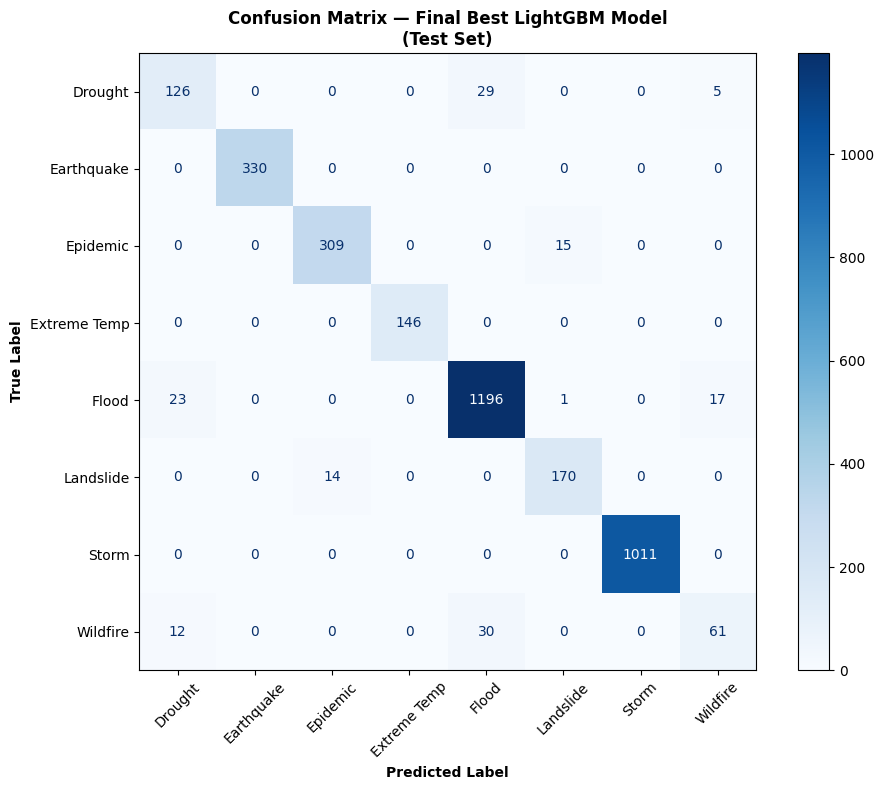

In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)

plt.title(
    "Confusion Matrix — Final Best LightGBM Model\n(Test Set)",
    fontweight="bold",
    fontsize=12,
)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.tight_layout()

plt.savefig("../models/final_confusion_matrix.png", dpi=300)

plt.show()
